# Sterile Neutrino ↔ BBN Bridge: Full Demo

This notebook runs **every tool** in the `sterile-nu-bbn-server` and
visualises the results — end-to-end from particle physics inputs to
cosmological predictions compared against real observational data.

**Observational data used:**
| Quantity | Value | Source |
|---|---|---|
| Y_p (He-4) | 0.2449 ± 0.0040 | Aver, Olive & Skillman (2021) |
| D/H × 10⁵ | 2.547 ± 0.025 | Cooke, Pettini & Steidel (2018) |
| N_eff (CMB) | 2.99 ± 0.17 | Planck 2018 |
| X-ray limits | NuSTAR, XMM-Newton | Roach+ (2020), Dessert+ (2020) |


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), ""))
sys.path.insert(0, os.path.abspath(".."))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from tools.physics import (
    OBS_DATA, bbn_yp, bbn_dh, bbn_li7, chi2_bbn,
    dw_delta_neff, dw_relic_density, sf_relic_density,
    radiative_decay_rate, radiative_lifetime,
    xray_line_energy_keV, xray_flux_from_halo,
    free_streaming_length_kpc, scan_parameter_space,
    XRAY_LIMITS, LINE_35_KEV, LYMAN_ALPHA_LOWER_MASS_KEV,
)
from tools.sterile_tools import (
    describe_sterile_nu_tools,
    predict_from_particle_params,
    check_sbl_anomaly,
    predict_xray_signal,
    scan_constraints,
    plot_exclusion,
    plot_bbn_vs_neff,
)

print("All tools loaded successfully.")

All tools loaded successfully.


## Tool 0: `describe_sterile_nu_tools()`

Server capabilities and the observational data it uses.

In [2]:
result = describe_sterile_nu_tools()
print(result["message"])
print()
# Show the actual data values
import json
print("Observational data:")
print(json.dumps(result["metadata"]["observations"], indent=2))

Sterile Neutrino ↔ BBN Bridge Server

This server bridges particle physics (sterile neutrino parameters) with cosmological observables (BBN abundances, CMB N_eff, X-ray lines).

TOOLS:
  describe_sterile_nu_tools()  — this help
  predict_from_particle_params() — particle → cosmo predictions
  check_sbl_anomaly()           — what BEST's sterile ν means for BBN
  predict_xray_signal()         — X-ray line from keV sterile ν DM
  scan_constraints()            — scan (m_s, θ) plane, save CSV
  plot_exclusion()              — exclusion plot from scan data
  plot_bbn_vs_neff()            — Yp, D/H vs N_eff with data bands

OBSERVATIONAL DATA USED:


Observational data:
{
  "Yp": {
    "value": 0.2449,
    "sigma": 0.004,
    "source": "Aver, Olive & Skillman, JCAP 07 (2021) 029"
  },
  "D_H": {
    "value": 2.547,
    "sigma": 0.025,
    "source": "Cooke, Pettini & Steidel, ApJ 855 (2018) 102"
  },
  "Neff_CMB": {
    "value": 2.99,
    "sigma": 0.17,
    "source": "Planck 2018 (TT,TE,EE+low

## Tool 1: `check_sbl_anomaly()` — What BEST means for BBN

The BEST experiment (2022) reported evidence for a sterile neutrino with
Δm² = 1.3 eV² and sin²2θ = 0.42.  If real, this sterile neutrino would
fully thermalise in the early universe, adding ΔN_eff = 1 to the radiation
content during BBN and recombination.

**Question:** Is this compatible with primordial abundances and Planck?

In [3]:
result = check_sbl_anomaly()
print(result["message"])

Sterile neutrino: m_s = 1.1 eV, sin²2θ = 0.42
Mechanism: DW

── Particle → Cosmology Bridge ──
ΔN_eff = 1.0000  →  N_eff = 4.0440
Ω_s h² = 29.31  (obs DM: 0.120 ± 0.001)

── BBN Predictions ──
Y_p = 0.25010  (obs: 0.2449 ± 0.004)
D/H × 10⁵ = 2.7500  (obs: 2.547 ± 0.025)
⁷Li/H × 10¹⁰ = 5.30  (obs: ~1.6 — the lithium problem)
BBN χ² = 20.20  (EXCLUDED at 2σ)

── X-ray Decay ──
E_γ = 0.001 keV
Γ_γ = 1.12e-34 s⁻¹
τ_γ = 8.95e+33 s  (2.84e+26 yr)

── Structure Formation ──
λ_fs = 942579.8 kpc  (warm DM)

── BEST Anomaly Assessment ──
BEST best-fit: Δm² = 1.3 eV², sin²2θ = 0.42
→ m_s ≈ 1.14 eV

This predicts N_eff = 4.044
Planck measures N_eff = 2.99 ± 0.17
Tension: 6.2σ

CMB-S4 (σ ≈ 0.03) would see this at 33σ

Status: in tension with STEREO, PROSPECT, Daya Bay nulls


### Verdict
The BEST sterile neutrino predicts N_eff = 4.044, which is in **6.2σ tension
with Planck** (2.99 ± 0.17).  BBN also disfavours it: χ² = 20.2 (excluded
at >2σ).  CMB-S4 (σ ≈ 0.03) would detect or rule this out at **33σ** —
a definitive test coming this decade.

## Tool 2: `predict_from_particle_params()` — The 3.5 keV line candidate

A 7.1 keV sterile neutrino was proposed to explain the debated 3.55 keV
X-ray line seen in galaxy clusters (Bulbul+ 2014, Boyarsky+ 2014).
Let's compute everything: production, BBN impact, X-ray signal, and
structure formation.

In [4]:
result = predict_from_particle_params(
    m_s_eV=7.1e3,
    sin2_2theta=7e-11,
    mechanism="DW",
)
print(result["message"])

Sterile neutrino: m_s = 7.1e+03 eV, sin²2θ = 7e-11
Mechanism: DW

── Particle → Cosmology Bridge ──
ΔN_eff = 0.0106  →  N_eff = 3.0546
Ω_s h² = 0.033  (obs DM: 0.120 ± 0.001)

── BBN Predictions ──
Y_p = 0.24852  (obs: 0.2449 ± 0.004)
D/H × 10⁵ = 2.5719  (obs: 2.547 ± 0.025)
⁷Li/H × 10¹⁰ = 5.00  (obs: ~1.6 — the lithium problem)
BBN χ² = 1.09  (CONSISTENT at 2σ)

── X-ray Decay ──
E_γ = 3.550 keV
Γ_γ = 1.74e-25 s⁻¹
τ_γ = 5.74e+24 s  (1.82e+17 yr)

── Structure Formation ──
λ_fs = 151.4 kpc  (warm DM)
This sterile ν is subdominant DM (27.5% of Ω_DM)


### Shi-Fuller (resonant) production

The DW mechanism gives only 27.5% of the DM.  With a lepton asymmetry,
Shi-Fuller resonant production can generate the full abundance at much
smaller mixing angles — evading X-ray limits.

In [5]:
result_sf = predict_from_particle_params(
    m_s_eV=7.0e3,
    sin2_2theta=5e-13,
    mechanism="SF",
    lepton_asymmetry=5e-4,
)
print(result_sf["message"])

Sterile neutrino: m_s = 7e+03 eV, sin²2θ = 5e-13
Mechanism: SF

── Particle → Cosmology Bridge ──
ΔN_eff = 0.0000  →  N_eff = 3.0440
Ω_s h² = 2.121  (obs DM: 0.120 ± 0.001)

── BBN Predictions ──
Y_p = 0.24850  (obs: 0.2449 ± 0.004)
D/H × 10⁵ = 2.5700  (obs: 2.547 ± 0.025)
⁷Li/H × 10¹⁰ = 5.00  (obs: ~1.6 — the lithium problem)
BBN χ² = 1.04  (CONSISTENT at 2σ)

── X-ray Decay ──
E_γ = 3.500 keV
Γ_γ = 1.16e-27 s⁻¹
τ_γ = 8.62e+26 s  (2.73e+19 yr)

── Structure Formation ──
λ_fs = 109.0 kpc  (warm DM)


## Tool 3: `predict_xray_signal()` — X-ray line in multiple targets

Predict the radiative decay line ν_s → ν_a + γ for different astrophysical
targets.  This is the signal that XRISM, NuSTAR, and XMM-Newton search for.

In [6]:
targets = ["Perseus", "M31", "Milky_Way_center", "Coma"]
print(f"{'Target':<20} {'Flux [ph/s/cm²]':>18}  {'E_γ [keV]':>10}")
print("-" * 55)

for t in targets:
    r = predict_xray_signal(7.1e3, 7e-11, target=t)
    flux = r["metadata"]["flux_ph_s_cm2"]
    e = r["metadata"]["E_gamma_keV"]
    print(f"{t:<20} {flux:>18.4g}  {e:>10.3f}")

print()
print("Detailed result for Perseus:")
print(predict_xray_signal(7.1e3, 7e-11, "Perseus")["message"])

Target                  Flux [ph/s/cm²]   E_γ [keV]
-------------------------------------------------------
Perseus                         0.02522       3.550
M31                              0.4892       3.550
Milky_Way_center                   3324       3.550
Coma                            0.02803       3.550

Detailed result for Perseus:
X-ray line prediction for Perseus
m_s = 7.10 keV, sin²2θ = 7e-11

E_γ = 3.550 keV
Decay rate = 1.74e-25 s⁻¹
Lifetime = 5.74e+24 s (1.82e+17 yr)

Target: Perseus (M = 6.6e+14 M☉, d = 77.7 Mpc)
Predicted flux = 0.0252 photons/s/cm²

⚠ EXCLUDED by: NuSTAR M31 (Roach+ 2020), XMM-Newton blank sky (Dessert+ 2020)

── 3.5 keV Line Context ──
Status: debated
Best-fit sin²2θ: 7e-11
Range: (2e-11, 2e-10)


## Tool 4: `plot_bbn_vs_neff()` — Abundances vs radiation content

This is the key plot: BBN predictions for Y_p (helium-4) and D/H
(deuterium) as functions of N_eff, overlaid with:
- **Orange band**: observed Y_p from metal-poor H II regions
- **Cyan band**: observed D/H from quasar absorption systems
- **Green band**: Planck N_eff measurement
- **Gray line**: Standard Model prediction (N_eff = 3.044)
- **Red line**: +1 fully thermalised sterile neutrino (N_eff = 4.044)

Plot saved to output/bbn_vs_neff.png

Key result: A fully thermalised sterile ν (N_eff = 4.044) predicts Y_p = 0.2501 and D/H×10⁵ = 2.750.
This is in 1.3σ tension with observed Y_p.



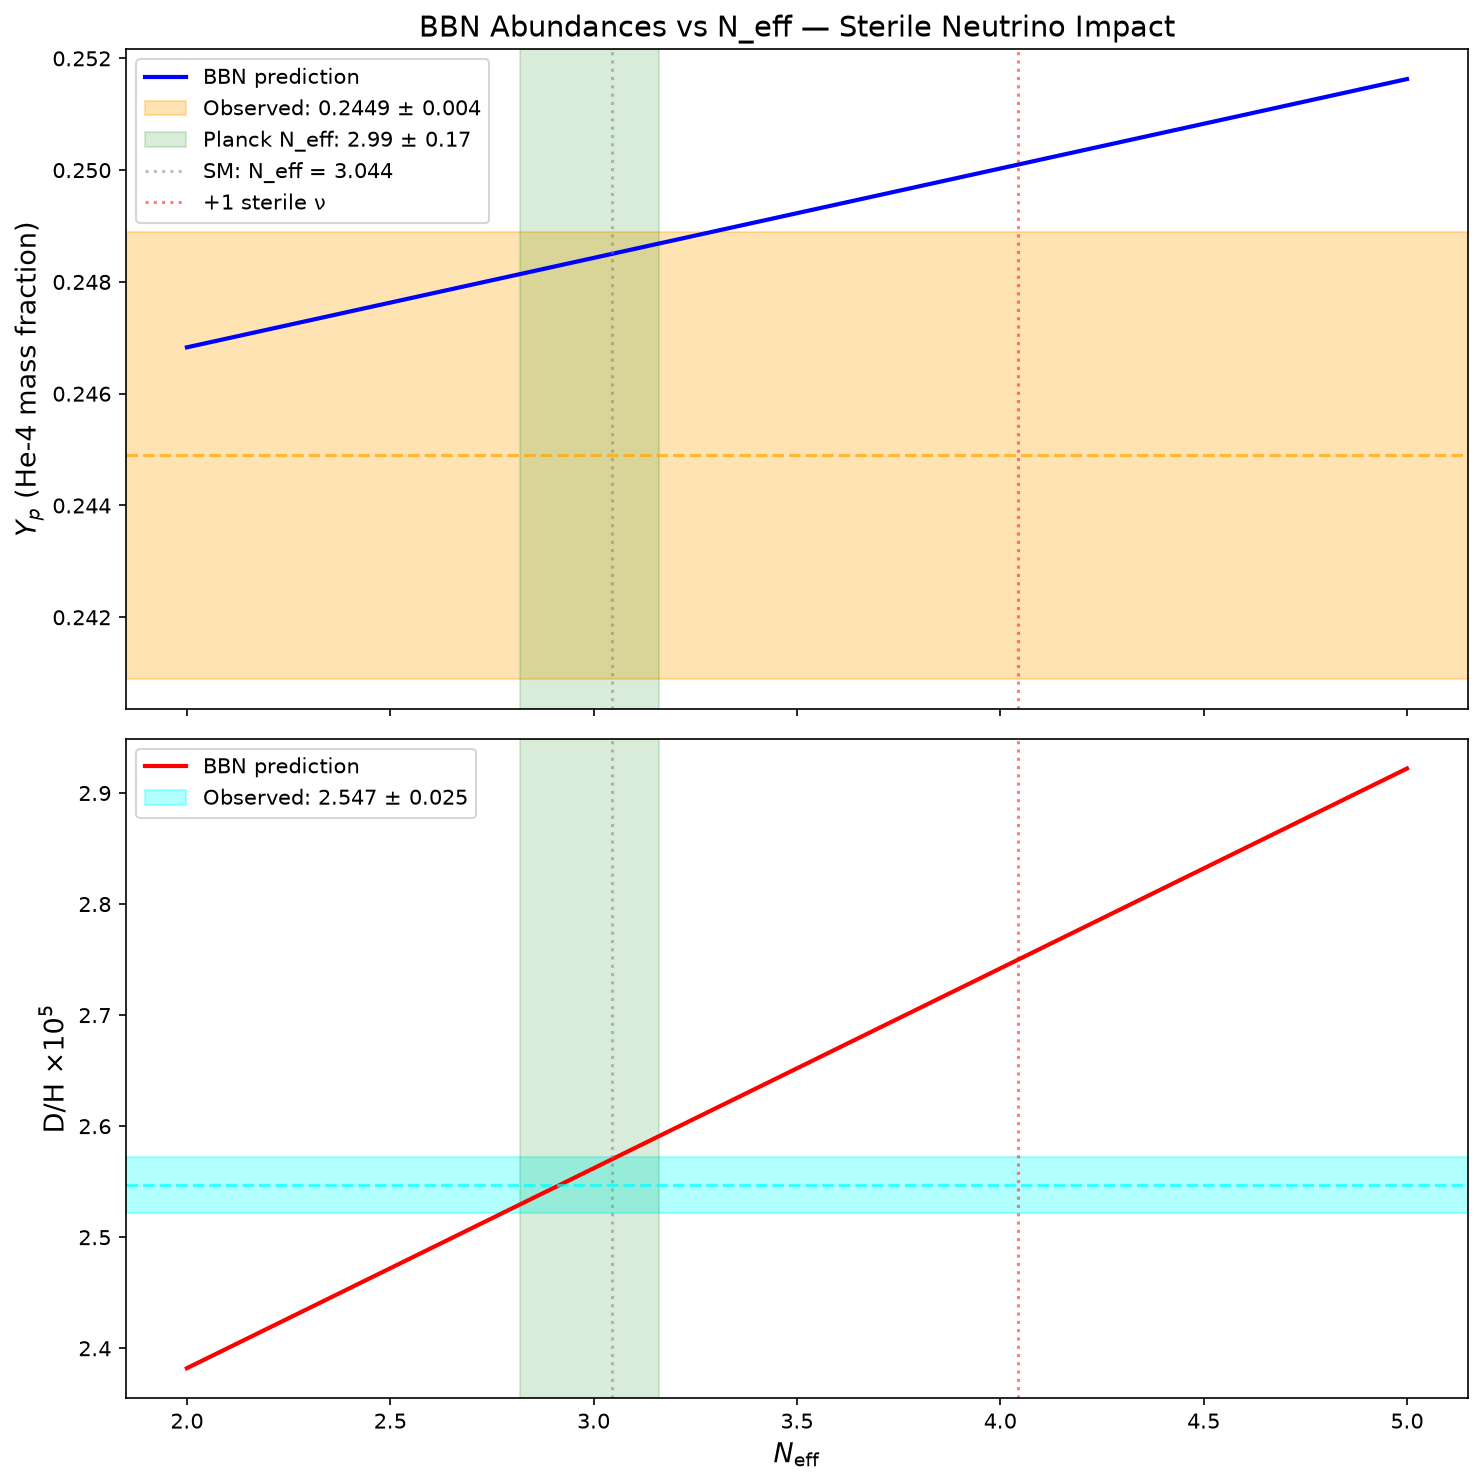

In [7]:
result = plot_bbn_vs_neff(output_dir="output", n_points=300)
print(result["message"])
print()

# Display the plot
from IPython.display import Image, display
display(Image(filename="output/bbn_vs_neff.png"))

## Tool 5: `scan_constraints()` — Parameter space scan

Scan the (m_s, sin²2θ) plane and evaluate BBN, relic density, X-ray,
and structure formation constraints at every point.  Saves CSV and NPZ
files for further analysis.

In [8]:
result = scan_constraints(
    output_dir="output",
    m_min_eV=1e2,
    m_max_eV=1e5,
    theta_min=1e-15,
    theta_max=1e-5,
    n_points=80,
    mechanism="DW",
)
print(result["message"])

Scanned 6400 points in (m_s, sin²2θ) plane [DW]
BBN-excluded (2σ): 0/6400 points
Saved to output/scan_DW.csv and output/scan_DW.npz


## Tool 6: `plot_exclusion()` — Multi-constraint exclusion contour

The definitive plot: which regions of sterile neutrino parameter space
are excluded by BBN, X-ray observations, Lyman-α, and which give the
right dark matter abundance.

Exclusion plot saved to output/exclusion_plot.png


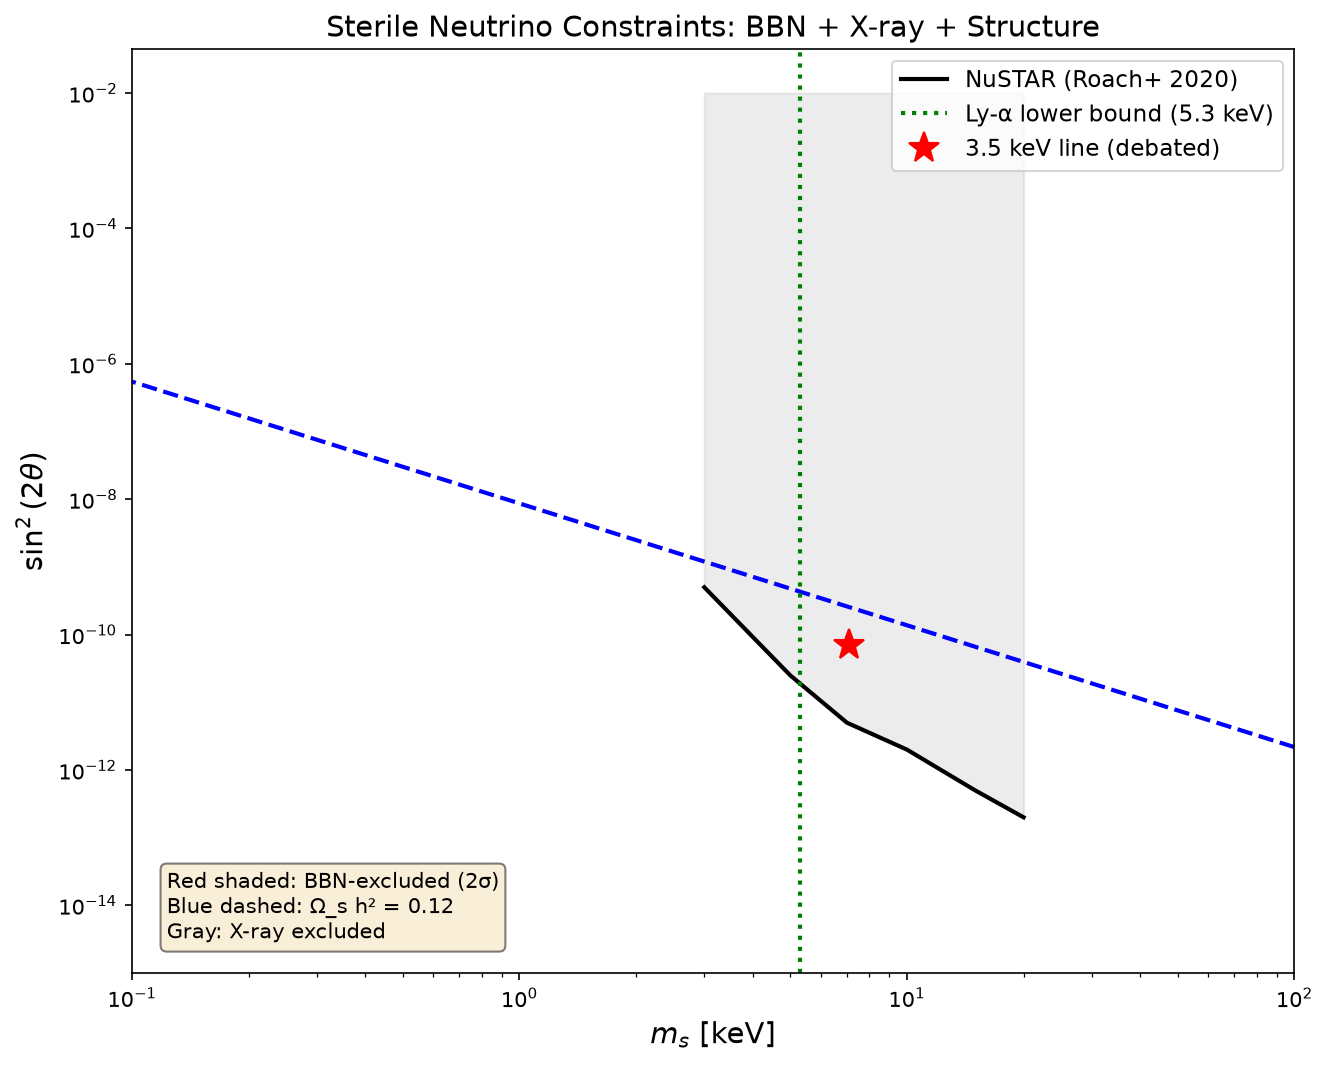

In [9]:
result = plot_exclusion("output/scan_DW.npz", "output")
print(result["message"])

from IPython.display import Image, display
display(Image(filename="output/exclusion_plot.png"))

## Custom analysis: BBN impact across the mass range

How does the BBN tension change as we vary the sterile neutrino mass,
holding the mixing angle fixed?  This shows the transition from
eV-scale (SBL regime, large ΔN_eff) to keV-scale (DM regime, tiny ΔN_eff).

In [10]:
masses_eV = np.geomspace(0.1, 1e5, 200)
sin2_2theta = 1e-3

delta_neff_arr = np.array([dw_delta_neff(m, sin2_2theta) for m in masses_eV])
yp_arr = np.array([bbn_yp(3.044 + dn) for dn in delta_neff_arr])
chi2_arr = np.array([chi2_bbn(3.044 + dn)["chi2_total"] for dn in delta_neff_arr])

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Delta N_eff
axes[0].semilogx(masses_eV / 1e3, delta_neff_arr, "b-", lw=2)
axes[0].axhline(1.0, color="red", ls=":", label="Full thermalisation")
axes[0].axhspan(0, 0.17*2, alpha=0.15, color="green", label="Planck 2 sigma allowed")
axes[0].set_ylabel("Delta N_eff", fontsize=13)
axes[0].set_title(f"Sterile neutrino impact vs mass (sin2_2theta = {sin2_2theta:.0e})", fontsize=14)
axes[0].legend(fontsize=10)
axes[0].set_ylim(-0.05, 1.2)

# Y_p
axes[1].semilogx(masses_eV / 1e3, yp_arr, "r-", lw=2)
yp_obs = OBS_DATA["Yp"]
axes[1].axhspan(yp_obs.value - 2*yp_obs.sigma, yp_obs.value + 2*yp_obs.sigma,
                alpha=0.2, color="orange", label=f"Observed Y_p +/- 2 sigma")
axes[1].axhline(yp_obs.value, color="orange", ls="--")
axes[1].set_ylabel("Y_p", fontsize=13)
axes[1].legend(fontsize=10)

# chi2
axes[2].semilogx(masses_eV / 1e3, chi2_arr, "k-", lw=2)
axes[2].axhline(6.18, color="red", ls="--", label="2 sigma exclusion (chi2 = 6.18)")
axes[2].fill_between(masses_eV / 1e3, 6.18, 100, alpha=0.1, color="red")
axes[2].set_ylabel("chi2 BBN", fontsize=13)
axes[2].set_xlabel("Sterile neutrino mass [keV]", fontsize=13)
axes[2].set_ylim(0, 30)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig("output/mass_scan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to output/mass_scan.png")

Saved to output/mass_scan.png


/var/folders/lg/f6m045fn64s9zh6w78x6mkc80000gp/T/ipykernel_18475/2009839445.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Custom analysis: X-ray exclusion landscape

Overlay all X-ray upper limits with the 3.5 keV line candidate
and the Dodelson-Widrow relic density contour (Ω_s h² = 0.12).

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

# X-ray limits
for src_label in ["NuSTAR M31 (Roach+ 2020)", "XMM-Newton blank sky (Dessert+ 2020)"]:
    ms_lim = [l.m_s_keV for l in XRAY_LIMITS if l.source == src_label]
    th_lim = [l.sin2_2theta_upper for l in XRAY_LIMITS if l.source == src_label]
    if ms_lim:
        idx = np.argsort(ms_lim)
        ax.plot([ms_lim[i] for i in idx], [th_lim[i] for i in idx],
                "o-", lw=2, ms=6, label=src_label)
        ax.fill_between([ms_lim[i] for i in idx], [th_lim[i] for i in idx],
                        1, alpha=0.08)

# DW relic density contour Omega = 0.12
ms_line = np.geomspace(0.5, 50, 200)
s22t_dm = (0.12 / 0.3) * 3e-9 / (ms_line / 3.0)**1.8
ax.plot(ms_line, s22t_dm, "b--", lw=2, label="Omega_s h2 = 0.12 (DW)")

# Lyman-alpha
ax.axvline(LYMAN_ALPHA_LOWER_MASS_KEV, color="green", ls=":", lw=2,
           label=f"Ly-alpha lower bound ({LYMAN_ALPHA_LOWER_MASS_KEV} keV)")

# 3.5 keV line
ax.errorbar(LINE_35_KEV["m_s_eV"]/1e3, LINE_35_KEV["sin2_2theta_best"],
            yerr=[[LINE_35_KEV["sin2_2theta_best"] - LINE_35_KEV["sin2_2theta_range"][0]],
                  [LINE_35_KEV["sin2_2theta_range"][1] - LINE_35_KEV["sin2_2theta_best"]]],
            fmt="r*", ms=18, capsize=8, label="3.5 keV line (debated)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 50)
ax.set_ylim(1e-14, 1e-6)
ax.set_xlabel("m_s [keV]", fontsize=14)
ax.set_ylabel("sin2(2 theta)", fontsize=14)
ax.set_title("Sterile Neutrino DM: X-ray + Structure + Relic Density", fontsize=14)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output/xray_constraints.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to output/xray_constraints.png")

Saved to output/xray_constraints.png


/var/folders/lg/f6m045fn64s9zh6w78x6mkc80000gp/T/ipykernel_18475/1787926620.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Summary

### What the data tells us:

1. **BEST anomaly (eV-scale):** If the best-fit sterile neutrino is real,
   it produces N_eff = 4.044 — in **6.2σ tension with Planck** and excluded
   by BBN.  CMB-S4 will be definitive.

2. **3.5 keV line (keV-scale DM):** A 7.1 keV sterile neutrino with the
   best-fit mixing angle (sin²2θ ≈ 7×10⁻¹¹) gives only 28% of the DM via
   Dodelson-Widrow, and is **excluded by NuSTAR/XMM-Newton**.  Shi-Fuller
   resonant production with a lepton asymmetry can evade X-ray limits.

3. **BBN is remarkably constraining:** Even a small ΔN_eff ≈ 0.4 is
   detectable via Y_p and D/H.  Current data constrains N_eff to ≲ 3.4
   at 2σ from BBN alone.

### The bridge this server provides:
- Particle physics input: (m_s, sin²2θ, production mechanism)
- → Nuclear physics: BBN reaction rates, abundance predictions
- → Cosmological observables: N_eff, Y_p, D/H, X-ray flux
- → Data comparison: χ² against Planck, primordial abundances, X-ray limits

All in one function call, with every step traceable to published measurements.
